In [1]:
import os
os.environ["AI2POT_PATH"] = "/data/home/liuhanyu/mycode/AI2Pot/"
os.environ["AI2POT_TEST_DATA_PATH"] = os.path.join(os.environ.get("AI2POT_PATH"),
                                                   "test",
                                                   "test_data",
                                                   "XYZ")

from typing import List

import torch
from ai2pot.models.mtp.linear_mtp_utils import LinearMtp4Extxyz

# 1. Plot e, f diagonal -- `ai2pot.models.mtp.linear_mtp_utils.LinearMtp4Extxyz`

In [2]:
checkpoint_path: str = os.path.join(os.environ.get("AI2POT_PATH"),
                                    "lightning_logs",
                                    "linear_mtp",
                                    "version_34",
                                    "checkpoints",
                                    "epoch=146-step=3675.ckpt")
extxyz_path: str = os.path.join(os.environ.get("AI2POT_TEST_DATA_PATH"),
                                               "11_NEP_potential_PbTe",
                                               "train_m.xyz")

linear_mtp4extxyz: LinearMtp4Extxyz = LinearMtp4Extxyz(checkpoint_path=checkpoint_path,
                                                       testset_path=extxyz_path,
                                                       has_virial=False,
                                                       map_location="cpu",
                                                       torch_float_dtype=torch.float32)

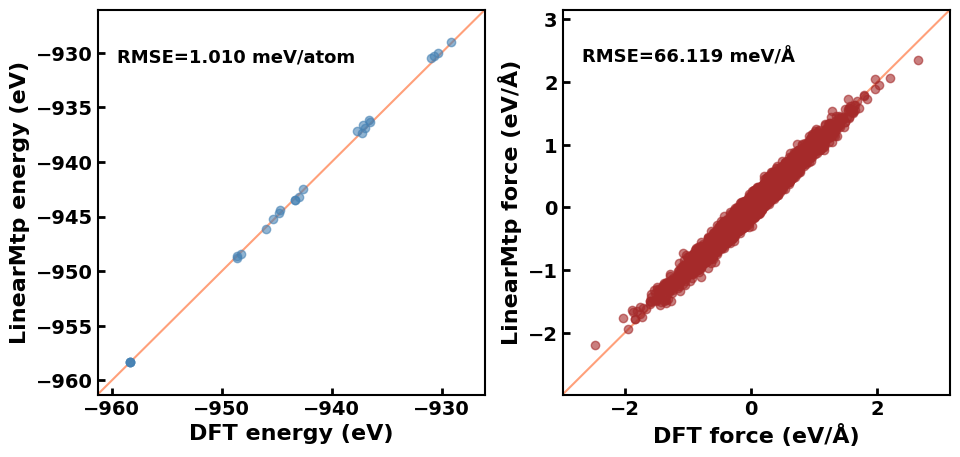

In [3]:
linear_mtp4extxyz.plot_ef_diagonal(save=False)

# 2. Calculate `RMSE`

In [5]:
e_rmse, f_rmse = linear_mtp4extxyz.calculate_ef_rmse()
print("RMSE summary:")
print("\t1. RMSE of energy = {0:.3f} meV".format(e_rmse * 1000))
print("\t2. RMSE of force = {0:.3f} meV/A".format(f_rmse * 1000))

RMSE summary:
	1. RMSE of energy = 1.010 meV
	2. RMSE of force = 66.119 meV/A
